# Notebook 04: Deep Learning Models

Trains and evaluates all 5 deep learning architectures (LSTM, GRU, CNN-LSTM,
TCN, CNN-LSTM+Attention) on the final 36-feature set.

Approach: sweep-then-finalize. Each architecture is first swept across
sequence windows [24, 72, 144] with a reduced epoch budget to find its best
window, then retrained at that window with full epochs and full patience.
This avoids window-choice bias toward any single architecture while keeping
total compute manageable (5 x 3 lightweight sweep runs + 5 full runs,
instead of 15 full runs).

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import joblib

from src.data_preprocessing import scale_data
from src.model import get_model
from src.train import (
    train_torch_model, evaluate_torch_model, create_sequences,
    run_window_sweep, get_device
)

pd.set_option("display.max_columns", None)
device = get_device()
print(f"Using device: {device}")

Using device: cpu


## 1. Load engineered data and final feature list

Same source as notebook 03 - train/test CSVs and the 36-feature list
saved at the end of notebook 02.

In [2]:
train_df = pd.read_csv("../data/processed/train_engineered.csv", index_col=0, parse_dates=True, date_format="%Y-%m-%d %H:%M:%S")
test_df = pd.read_csv("../data/processed/test_engineered.csv", index_col=0, parse_dates=True, date_format="%Y-%m-%d %H:%M:%S")

with open("../data/processed/selected_features.txt", "r") as f:
    selected_features = f.read().splitlines()

print(f"Train: {train_df.shape}, Test: {test_df.shape}, Features: {len(selected_features)}")

Train: (15672, 51), Test: (3919, 51), Features: 36


## 2. Scale and hold out a validation split

A validation split is carved from the end of the training set (last 15%,
still temporally ordered) for early stopping and window comparison during
the sweep. Test set stays fully held out until final evaluation.

In [3]:
X_train_full, X_test, y_train_full, y_test, feature_scaler, target_scaler = scale_data(
    train_df, test_df, selected_features, target_col="Appliances"
)

val_split_idx = int(len(X_train_full) * 0.85)
X_train, X_val = X_train_full[:val_split_idx], X_train_full[val_split_idx:]
y_train, y_val = y_train_full[:val_split_idx], y_train_full[val_split_idx:]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (13321, 36), Val: (2351, 36), Test: (3919, 36)


## 3. Sweep phase - find the best window per architecture

Each architecture is swept across windows [24, 72, 144] with a reduced
budget (15 epochs, patience 3) - enough to see which window is trending
better without paying for full convergence 15 times over.

In [4]:
architectures = ["lstm", "gru", "cnn_lstm", "tcn", "cnn_lstm_attention"]
windows_to_try = (24, 72, 144)

sweep_results = {}
best_windows = {}

for arch in architectures:
    print(f"\nSweeping {arch}...")
    best_window, results = run_window_sweep(
        arch, X_train, y_train, X_val, y_val,
        n_features=len(selected_features),
        windows=windows_to_try,
        sweep_epochs=15, sweep_patience=3,
        device=device, verbose=True,
    )
    sweep_results[arch] = results
    best_windows[arch] = best_window

sweep_df = pd.DataFrame(sweep_results).T
sweep_df["best_window"] = pd.Series(best_windows)
sweep_df


Sweeping lstm...


  window=24: best val_loss=0.013052


  window=72: best val_loss=0.013029


  window=144: best val_loss=0.013370
Best window for lstm: 72

Sweeping gru...


  window=24: best val_loss=0.013398


...

  window=144: best val_loss=0.013930
Best window for tcn: 24

Sweeping cnn_lstm_attention...


  window=24: best val_loss=0.013204


  window=72: best val_loss=0.018933


  window=144: best val_loss=0.023054
Best window for cnn_lstm_attention: 24


,24,72,144,best_window
lstm,0.013052,0.013029,0.013370,72
gru,0.013398,0.012798,0.013295,72
cnn_lstm,0.012553,0.012272,0.013328,72
tcn,0.013233,0.013482,0.013930,24
cnn_lstm_attention,0.013204,0.018933,0.023054,24


Three architectures (lstm, gru, cnn_lstm) picked window=72 as best here,
while tcn and cnn_lstm_attention still picked window=24. cnn_lstm_attention degrades sharply at longer windows (0.0132 to 0.0231), the attention mechanism doesn't make good use of the
extra context with this amount of training data. The 72-vs-24 split
across the other three is a small effect (differences of 0.0003-0.0006
in validation loss), not a dramatic one.

## 4. Finalize phase - full training at each architecture's best window

Each architecture is retrained at its own best window with full epochs
(60) and full patience (10), so early stopping has room to find a real
convergence point rather than the artificially short sweep budget.

In [5]:
final_models = {}
final_histories = {}
final_results = []

for arch in architectures:
    window = best_windows[arch]
    print(f"\nTraining {arch} at window={window}...")

    X_tr_seq, y_tr_seq = create_sequences(X_train, y_train, window)
    X_val_seq, y_val_seq = create_sequences(X_val, y_val, window)
    X_test_seq, y_test_seq = create_sequences(X_test, y_test, window)

    model = get_model(arch, n_features=len(selected_features))
    model, history = train_torch_model(
        model, X_tr_seq, y_tr_seq, X_val_seq, y_val_seq,
        epochs=60, patience=10, batch_size=64, device=device, verbose=True,
    )

    results = evaluate_torch_model(
        model, X_test_seq, y_test_seq, target_scaler=target_scaler,
        model_name=arch, device=device,
    )
    results["window"] = window

    final_models[arch] = model
    final_histories[arch] = history
    final_results.append(results)

    print(f"{arch} (window={window}): {results}")


Training lstm at window=72...


Epoch 1/60 - train_loss: 0.0291 - val_loss: 0.0153


Epoch 6/60 - train_loss: 0.0151 - val_loss: 0.0136


Epoch 11/60 - train_loss: 0.0140 - val_loss: 0.0134


Epoch 16/60 - train_loss: 0.0133 - val_loss: 0.0137


...

Epoch 6/60 - train_loss: 0.0155 - val_loss: 0.0139


Epoch 11/60 - train_loss: 0.0139 - val_loss: 0.0137


Epoch 16/60 - train_loss: 0.0132 - val_loss: 0.0139


Epoch 21/60 - train_loss: 0.0125 - val_loss: 0.0143


Early stopping at epoch 22 (best val_loss: 0.0137)
cnn_lstm_attention (window=24): {'model': 'cnn_lstm_attention', 'MAE': 21.9499, 'RMSE': 29.6336, 'MAPE': 29.9925, 'R2': 0.406, 'window': 24}


## 5. Deep learning comparison table

In [6]:
dl_comparison = pd.DataFrame(final_results).sort_values("RMSE").reset_index(drop=True)
dl_comparison

,model,MAE,RMSE,MAPE,R2,window
0,cnn_lstm,19.8555,26.8732,27.1462,0.5127,72
1,lstm,20.4271,28.1096,27.9723,0.4668,72
2,tcn,20.7477,28.1787,28.4109,0.4628,24
3,gru,21.6285,28.8777,29.9177,0.4372,72
4,cnn_lstm_attention,21.9499,29.6336,29.9925,0.4060,24


CNN-LSTM performs best among the deep models this time (RMSE 26.87,
R2 0.513), with GRU actually the weakest of the five now (RMSE 28.88,
R2 0.437). All 5 architectures underperform both Phase 3
baselines by a wide margin - Linear Regression (RMSE 21.25, R2 0.698)
still leads overall, and by more than before. Consistent with
Appliances_lag1 dominating permutation importance in notebook 02 (~0.79):
the target's relationship to its own recent past is close to linear, so
Linear Regression's closed-form fit outperforms sequence models learning
the same relationship through gradient descent on ~13,300 rows. Deep
learning's advantage did not materialize here, and that is itself a
legitimate finding for the report - not every dataset rewards
architectural complexity.

## 6. Learning curves

Train/val loss per epoch for each architecture, to check for overfitting
(val loss rising while train loss keeps falling) or underfitting (both
staying flat and high).

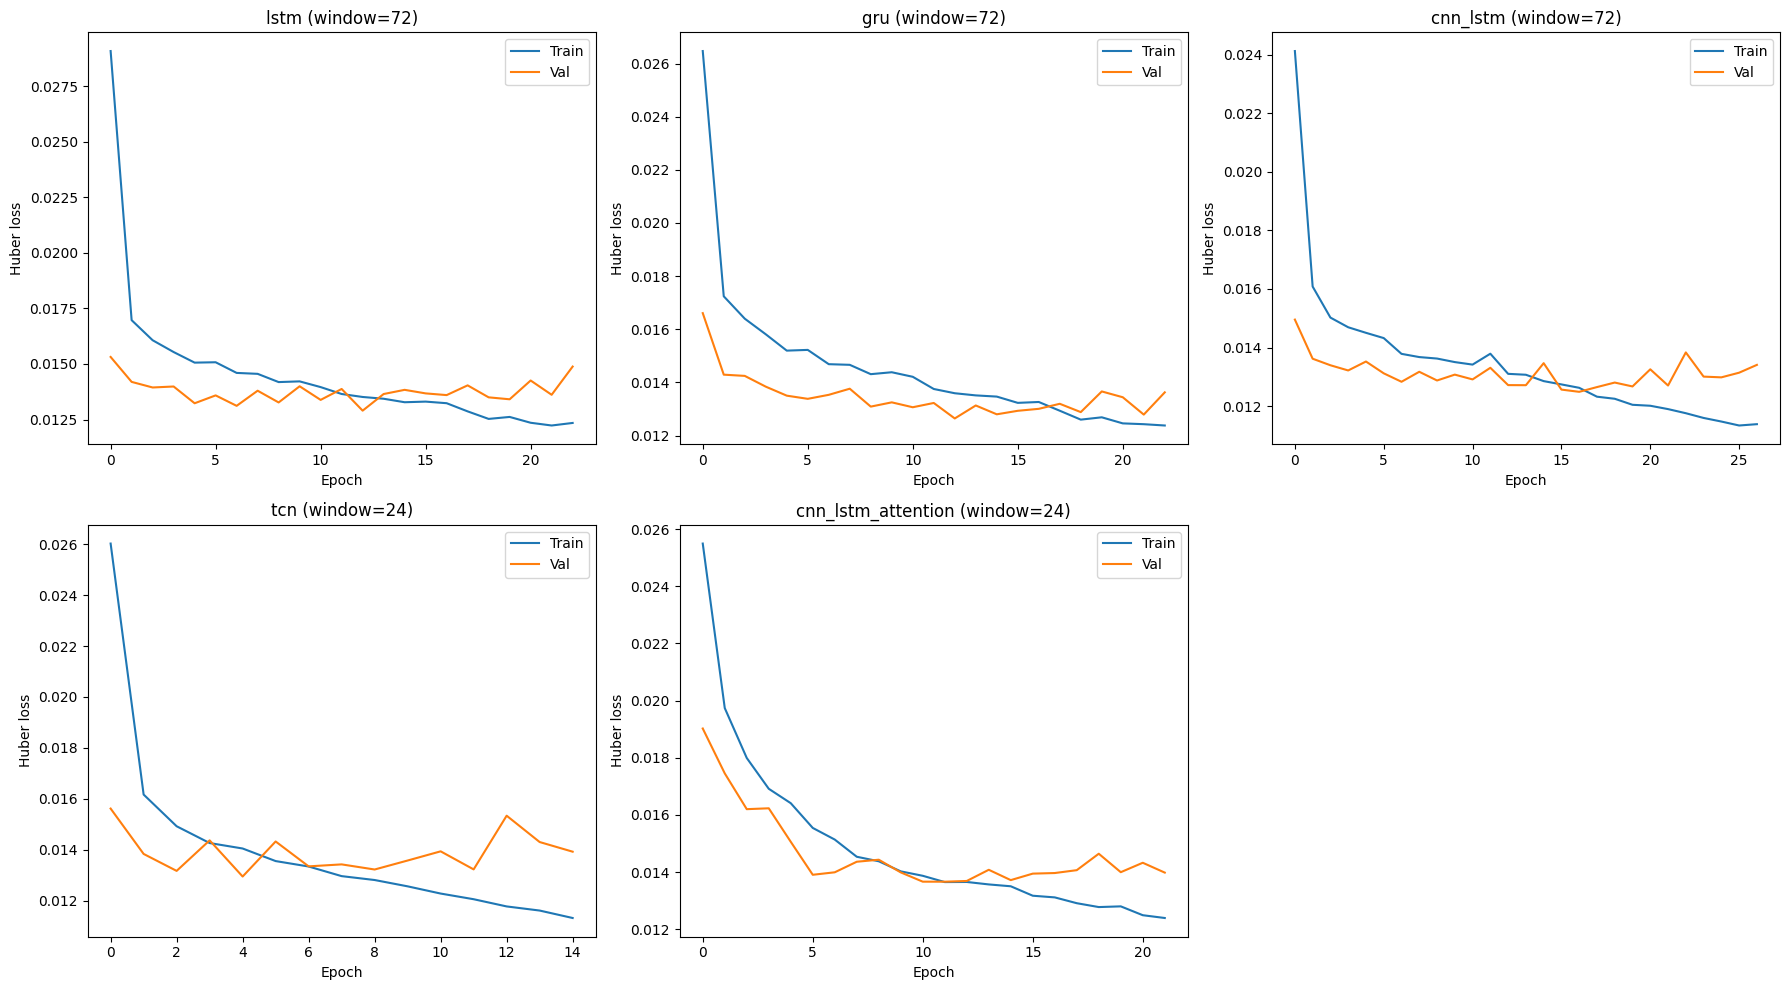

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, arch in enumerate(architectures):
    history = final_histories[arch]
    axes[i].plot(history["train_loss"], label="Train")
    axes[i].plot(history["val_loss"], label="Val")
    axes[i].set_title(f"{arch} (window={best_windows[arch]})")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Huber loss")
    axes[i].legend()

axes[-1].axis("off")
plt.tight_layout()
plt.savefig("../reports/figures/12_learning_curves.png", dpi=150)
plt.show()

All 5 models show healthy convergence - train loss decreases steadily,
val loss flattens and early stopping triggers before divergence, so
there's no overfitting problem. The gap between train and val loss stays
small throughout, meaning these models are not overfitting, they are
underfitting the amount of signal Linear Regression already extracts
directly - the ceiling here is representational, not a training bug.

## 7. Extract attention weights (for notebook 05)

Saves a sample batch of attention weights from the CNN-LSTM+Attention
model now, so notebook 05 can visualize which time steps the model relies
on most without needing to reload and re-run this model there.

In [8]:
attn_model = final_models["cnn_lstm_attention"]
attn_window = best_windows["cnn_lstm_attention"]
X_test_seq_attn, y_test_seq_attn = create_sequences(X_test, y_test, attn_window)

attn_model.eval()
sample_x = torch.tensor(X_test_seq_attn[:200], dtype=torch.float32).to(device)
with torch.no_grad():
    _, attn_weights = attn_model(sample_x, return_attention=True)

attn_weights_np = attn_weights.cpu().numpy()
np.save("../data/processed/attention_weights_sample.npy", attn_weights_np)
print(f"Saved attention weights: {attn_weights_np.shape}")

Saved attention weights: (200, 24)


## 8. Combine with baseline results and save everything

In [9]:
baseline_comparison = pd.read_csv("../reports/baseline_results.csv")
full_comparison = pd.concat([baseline_comparison, dl_comparison], ignore_index=True)
full_comparison = full_comparison.sort_values("RMSE").reset_index(drop=True)
full_comparison.to_csv("../reports/full_model_comparison.csv", index=False)

for arch, model in final_models.items():
    torch.save(model.state_dict(), f"../models/{arch}.pt")

joblib.dump(best_windows, "../models/best_windows.pkl")

print("Saved all models, window choices, and combined comparison table.")
full_comparison

Saved all models, window choices, and combined comparison table.


,model,MAE,RMSE,MAPE,R2,window
0,Linear Regression,13.5960,21.2454,17.7672,0.6976,NaN
1,cnn_lstm,19.8555,26.8732,27.1462,0.5127,72.0
2,Random Forest,20.7375,27.7119,27.2843,0.4856,NaN
3,lstm,20.4271,28.1096,27.9723,0.4668,72.0
4,tcn,20.7477,28.1787,28.4109,0.4628,24.0
5,gru,21.6285,28.8777,29.9177,0.4372,72.0
6,cnn_lstm_attention,21.9499,29.6336,29.9925,0.4060,24.0


## Summary

- Swept all 5 architectures across windows [24, 72, 144]; lstm/gru/cnn_lstm
  picked window=72, tcn/cnn_lstm_attention picked window=24, each
  finalized at its own best window
- Full comparison across all 7 models (2 baselines + 5 deep learning)
  saved to reports/full_model_comparison.csv
- Linear Regression wins overall (RMSE 21.25, R2 0.698). CNN-LSTM is the
  strongest deep learning model (RMSE 26.87, R2 0.513) on this feature
  set, ahead of GRU, which was the strongest on an earlier (leakier)
  feature set - the ranking among deep architectures is not very stable,
  but none of them come close to the baselines either way
- Attention weights saved for notebook 05 visualization

Next: notebooks/05_Optimization_Evaluation.ipynb - residual diagnostics,
attention weight visualization, and full metrics comparison across all
7 models.